In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model

In [2]:
df=pd.read_csv("ice-cream.csv")
print(df)

           Date  DayOfWeek    Month  Temperature  Rainfall  IceCreamsSold
0    2025-04-01    Tuesday    April         59.4      0.74             61
1    2025-04-03   Thursday    April         53.6      0.28             33
2    2025-04-06     Sunday    April         51.4      0.14             21
3    2025-04-07     Monday    April         50.8      0.06             23
4    2025-04-08    Tuesday    April         57.4      0.79             51
..          ...        ...      ...          ...       ...            ...
195  2025-10-27     Monday  October         69.7      0.28            115
196  2025-10-28    Tuesday  October         54.4      0.74             33
197  2025-10-29  Wednesday  October         65.8      0.38             86
198  2025-10-30   Thursday  October         54.4      0.69             38
199  2025-10-31     Friday  October         69.2      0.04            114

[200 rows x 6 columns]


In [3]:
df.head(10)

,Date,DayOfWeek,Month,Temperature,Rainfall,IceCreamsSold
0,2025-04-01,Tuesday,April,59.4,0.74,61
1,2025-04-03,Thursday,April,53.6,0.28,33
2,2025-04-06,Sunday,April,51.4,0.14,21
3,2025-04-07,Monday,April,50.8,0.06,23
4,2025-04-08,Tuesday,April,57.4,0.79,51
5,2025-04-09,Wednesday,April,59.9,0.25,73
6,2025-04-10,Thursday,April,55.5,0.07,43
7,2025-04-11,Friday,April,58.0,0.14,57
8,2025-04-12,Saturday,April,52.5,0.11,31
9,2025-04-14,Monday,April,54.6,0.33,41


In [9]:
model=linear_model.LinearRegression()
model.fit(df[['IceCreamsSold']],df.Rainfall)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


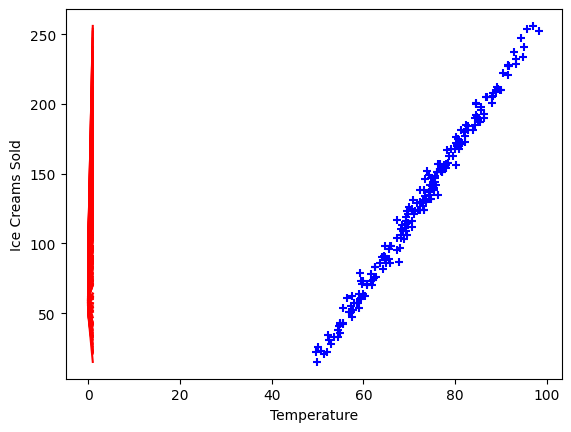

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.scatter(df.Temperature,df.IceCreamsSold,color='blue', marker='+')
plt.plot((df.Temperature,df.IceCreamsSold),color='red')
plt.xlabel("Temperature")
plt.ylabel("Ice Creams Sold")
plt.show()

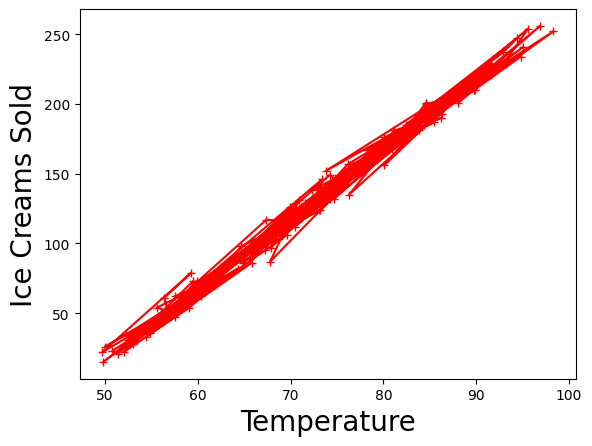

In [33]:
plt.plot(df.Temperature,df.IceCreamsSold,color='red', marker='+')
plt.xlabel("Temperature",fontsize=20)

plt.ylabel("Ice Creams Sold",fontsize=20)
plt.show()

In [14]:
model.coef_

array([-6.10544706e-05])

In [15]:
model.predict([[3000]])

c:\Users\Vishwanath\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.10816994])

In [16]:
model.intercept_

np.float64(0.291333353248778)

In [17]:
import pickle
pickle.dump(model,open('model.pkl','wb'))

In [18]:
model=pickle.load(open('model.pkl','rb'))
model.predict([[3000]])

c:\Users\Vishwanath\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.10816994])

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df[['IceCreamsSold']],df.Rainfall,test_size=0.2)
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
len(X_train)

160

In [26]:
from sklearn.linear_model import LinearRegression
clf=LinearRegression()
clf.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_train

49     0.41
174    0.46
162    0.06
25     0.25
170    0.71
       ... 
64     0.30
92     0.31
118    0.12
33     0.12
48     0.44
Name: Rainfall, Length: 160, dtype: float64

In [28]:
y_test

192    0.25
171    0.14
177    0.21
151    0.19
153    0.11
110    0.18
50     0.53
94     0.16
2      0.14
194    0.02
116    0.47
47     0.06
9      0.33
147    0.06
154    0.91
176    0.18
3      0.06
190    0.06
135    0.19
188    0.27
129    0.16
189    1.50
69     0.28
89     0.24
71     0.56
112    0.31
159    0.02
108    0.17
158    0.13
57     0.19
107    0.06
96     0.27
104    0.44
77     0.28
182    0.26
168    0.24
21     0.12
187    0.14
179    0.30
23     0.51
Name: Rainfall, dtype: float64

In [8]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 865.2 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.0 MB 1.0 MB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.0 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.0 MB 2.5 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.0 MB 2.9 MB/s eta 0:00:02
   ------------------------ --------------- 5.0/8.0 MB 3.2 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/8.0 MB 3.5


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
